**LIBRARIES**

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\LENOVO
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

**LOAD DATA**

In [77]:
df = pd.read_csv("../data/satusehat_reviews_slang_cleaned.csv")
sample_df = df.sample(n=20, random_state=42)

**STOPWORD REMOVAL**

In [78]:
stop_words = set(stopwords.words('indonesian'))

In [79]:
custom_stopwords = {
    'eh', 'ah', 'oh', 'ya', 'yah', 'deh', 'sih', 'lah', 'nih', 'tuh',
    'u', 'e', 'dan', 'atau', 'apa', 'apakah', 'oke', 'ok',
    'whatsa', 'henti', 'bete', 'aneh', 'wes',
}

In [80]:
stop_words.update(custom_stopwords)

In [81]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

In [82]:
sample_df_clean = sample_df.copy()
sample_df_clean["content"] = sample_df_clean["content"].apply(remove_stopwords)

**STEMMING**

In [83]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [84]:
def stemming(text):
    return stemmer.stem(text)

In [85]:
sample_df_clean["content"] = sample_df_clean["content"].apply(stemming)

**GABUNG SEMUA TEXT**

In [86]:
text = " ".join(sample_df_clean["content"].astype(str))

**WORDCLOUD**

In [87]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(text)

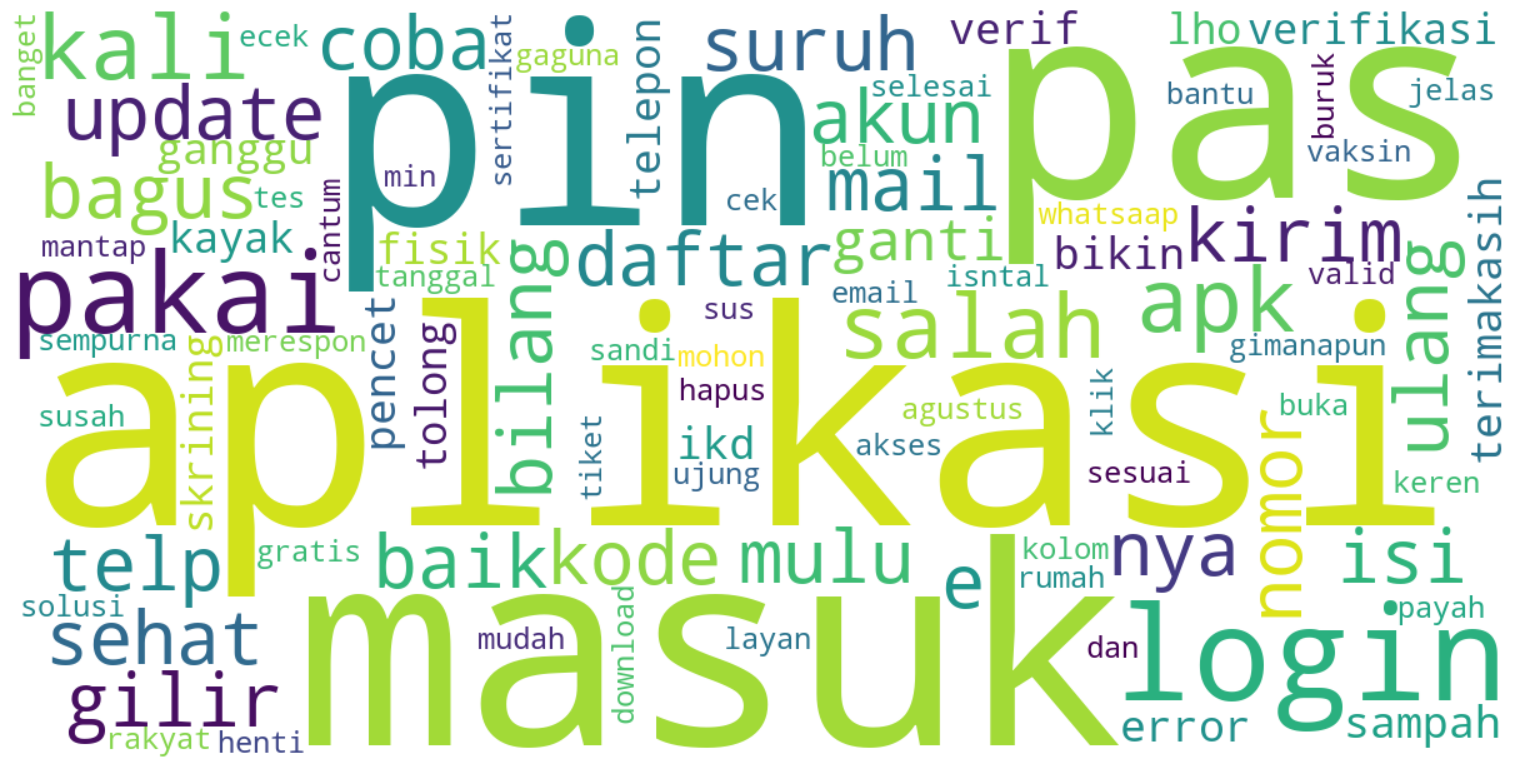

In [88]:
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()